In [1]:
#####################################################################################################################################
##### This script evaluates the performance of the LemonIte network against PKN
##### This will be done in two different approaches:
#####       1. Classic evaluation metrics (accuracy, precision, recall, F1-score) of LemonIte network against the ground truth data
#####       2. Evaluation of average shortest paths for metabolite-gene pairs from LemonIte network in the PKN
#####################################################################################################################################

In [2]:
# import modules and set working directory
import os
import pandas as pd
import numpy as np
import networkx as nx
from multiprocessing import Pool
from scipy.stats import hypergeom
from adjustText import adjust_text
import matplotlib.pyplot as plt
import seaborn as sns

base_dir = '/home/borisvdm/Documents/PhD/Lemonite/Lloyd-Price_IBD/results/'
run_id = 'LemonTree/'
percentile = 2
n_modules = 'selected_86'
    
workdir = base_dir + run_id
os.chdir(workdir)

dataset_file = workdir + f'/Preprocessing/LemonPreprocessed_complete.txt'
lemonnetwork_file = workdir + f'/Networks/LemonNetwork_percentile{percentile}_{n_modules}modules.txt'
PKNnetwork_file = '/home/borisvdm/Documents/PhD/Lemonite/PKN/Lemonite_PKN.tsv'
annotated_mets = '/home/borisvdm/Documents/PhD/gut_brain/IBD/Lloyd-Price2019/data/name_map.txt' # paste metabolite list in MetaboAnalyst id mapping tool and download result + manually look into annotations
#metabolite_interactions_file = workdir + f'PKN/HMDB_metabolites_gene_interactions.tsv'


TF_regulator_file = workdir+'ModuleViewer_files/Lovering.percentile'+str(percentile)+'_list.txt'
metabolite_regulator_file = workdir+'ModuleViewer_files/Metabolite.percentile'+str(percentile)+'_list.txt'
metabolite_random_regulator_file = workdir+'ModuleViewer_files/Metabolite.randomreg_list.txt'
clusterfile = workdir+'Lemon_out/clusters_list.txt'
metabolite_interactions_file = '/home/borisvdm/Documents/PhD/Lemonite/PKN/HMDB_metabolites_gene_interactions.csv'

# Read predicted network and create some dictionaries to map modules to genes, regulators to genes, etc

In [3]:
lemonnetwork = pd.read_csv(lemonnetwork_file, sep='\t')
lemonnetwork
lemonnetwork_metabolites = lemonnetwork[lemonnetwork['Type'] == 'Metabolite-gene']
print(lemonnetwork_metabolites)
# create dict with metabolite-gene interactions
metabolites2genes = {}
for index, row in lemonnetwork_metabolites.iterrows():
    if row['Regulator'] not in metabolites2genes:
        metabolites2genes[row['Regulator']] = [row['Target']]
    else:
        metabolites2genes[row['Regulator']].append(row['Target'])

genes_in_dataset = lemonnetwork['Target'].unique()
print(f'There are {len(genes_in_dataset)} genes in the dataset')

                  Regulator    Target     Score  Lemon_module             Type
18170             C20_1_LPC    IL27RA  0.270049             0  Metabolite-gene
18171             C20_1_LPC     IL21R  0.270049             0  Metabolite-gene
18172             C20_1_LPC      CD28  0.270049             0  Metabolite-gene
18173             C20_1_LPC   PPP1R18  0.270049             0  Metabolite-gene
18174             C20_1_LPC     SASH3  0.270049             0  Metabolite-gene
...                     ...       ...       ...           ...              ...
41357  C36_4_PC_plasmalogen    HOXA11  0.127858            95  Metabolite-gene
41358  C36_4_PC_plasmalogen   C8orf48  0.127858            95  Metabolite-gene
41359  C36_4_PC_plasmalogen   SLC22A3  0.127858            95  Metabolite-gene
41360  C36_4_PC_plasmalogen  ADAMTS14  0.127858            95  Metabolite-gene
41361  C36_4_PC_plasmalogen     TRPC3  0.127858            95  Metabolite-gene

[23192 rows x 5 columns]
There are 3543 genes in th

In [4]:
# Funtion to create a dictionary with all regulators per module (start from the regulators.fold file created using LemonTree_downstream.py)
def get_regulators(regfile):
    regs = {}
    with open(regfile) as f:
        for line in f:
            module = line.split('\t')[0]
            regulators = line.rstrip().split('\t')[1].split('|')
            regs[module] = regulators
    return regs

module2TFs = get_regulators(TF_regulator_file)
module2mets = get_regulators(metabolite_regulator_file)
module2genes = get_regulators(clusterfile)
module2mets_random = get_regulators(metabolite_random_regulator_file)

print('modules:', module2genes)
print('TFs:', module2TFs)
print('mets:', module2mets)
print('mets_random:', module2mets_random)


modules: {'0': ['IL27RA', 'IL21R', 'CD28', 'PPP1R18', 'SASH3', 'HLA-DOB', 'CD3D', 'WDFY4', 'AGAP2', 'TIGIT', 'NCKAP1L', 'MAP4K1', 'SCIMP', 'LBH', 'NCF1', 'CD53', 'CD79A', 'PHACTR1', 'CD48', 'ITGAL', 'CYTIP', 'POU2F2', 'RASAL3', 'SPOCK2', 'ICOS', 'PTPN7', 'FGD2', 'TLR6', 'HLA-DOA', 'SP140', 'BTK', 'SLAMF6', 'LTA', 'CORO1A', 'IKZF1', 'ACAP1', 'IL16', 'AIM2', 'LCK', 'TRAF3IP3', 'PPP1R16B', 'FMNL3', 'DOK3', 'ARHGDIB', 'CD180', 'PCED1B', 'SNX20', 'WIPF1', 'P2RY10', 'CD52', 'PARVG', 'PYHIN1', 'GMFG', 'RAC2', 'RASGRP1', 'JAK3', 'ANKRD44', 'PRKCB', 'SH2D3C', 'DENND1C', 'TRAF1', 'LAT2', 'APBB1IP', 'NLRC3', 'CARD11', 'LCP1', 'WAS', 'RHOH', 'SUSD3', 'GRAP', 'ARHGAP25', 'TMEM156', 'FAM78A', 'PLCG2', 'P2RY8', 'PTPRC', 'SELL', 'FGD3', 'ARHGAP15', 'RUNX3', 'KLHL6', 'ADAM19', 'ZNF831', 'DOCK2', 'RFTN1', 'RASSF2', 'KMO', 'SH2D1A', 'LIMD2', 'MYO1G', 'FMNL1', 'NFATC1', 'ARHGAP30', 'ITK', 'CD5', 'TNFSF8', 'HCLS1', 'PIK3CD', 'ARHGAP9', 'CD6'], '1': ['ITGA5', 'ARHGEF15', 'RGCC', 'THSD1', 'LOXL2', 'PCDH17', 

# Subset metabolite-gene interactions file for metabolites that are in the dataset

In [5]:
interactions = pd.read_csv(metabolite_interactions_file, sep='\t')
interactions

/tmp/ipykernel_214267/3026841620.py:1: DtypeWarning: Columns (15,16,17,18,19,20) have mixed types. Specify dtype option on import or set low_memory=False.
  interactions = pd.read_csv(metabolite_interactions_file, sep='\t')


,Name,HMDB,ChEBI,KEGG,PubChem,IUPAC_Name,SMILES,InChIKey,PDB_ID,Kingdom,...,IntAct,UniProtKB,chEMBL,LINCS,STITCH,BioGRID,Human1_GEM_dist1,Human1_GEM_dist2,MetalinksDB,All_database_interactions
0,1-Methylhistidine,HMDB0000001,50599.0,C01152,92105.0,(2S)-2-amino-3-(1-methyl-1H-imidazol-4-yl)prop...,CN1C=NC(C[C@H](N)C(O)=O)=C1,BRMWTNUJHUMWMS-LURJTMIESA-N,NaN,Organic acids and derivatives,...,none,none,none,NaN,NaN,ACTA1,NaN,NaN,NaN,ACTA1
1,"1,3-Diaminopropane",HMDB0000002,15725.0,C00986,428.0,"propane-1,3-diamine",NCCCN,XFNJVJPLKCPIBV-UHFFFAOYSA-N,NaN,Organic nitrogen compounds,...,none,DHPS|DS|DHPS|DHPS|DHPS|DHPS|DHPS|DHPS,none,NaN,NaN,NaN,AOC1|AOC2|AOC3|DHPS|SLC22A1|SLC22A2|SLC22A3,AADAC|AASDH|ABHD12|ABHD6|ACAA1|ACAA2|ACE|ACE2|...,NaN,DHPS|DS|DHPS|DHPS|DHPS|DHPS|DHPS|DHPS|AOC1|AOC...
2,2-Ketobutyric acid,HMDB0000005,30831.0,C00109,58.0,2-oxobutanoic acid,CCC(=O)C(O)=O,TYEYBOSBBBHJIV-UHFFFAOYSA-N,NaN,Organic acids and derivatives,...,none,RIDA|HRSP12|SDS|SDH|SDSL|GOT1|CTH|AGXT2|AGT2|A...,none,NaN,NaN,NaN,BCKDHA|BCKDHB|CTH|GPT|LDHAL6A|LDHAL6B|LDHB|LDH...,AADAC|AADAT|ABAT|ABHD12|ABHD6|ACE|ACE2|ACHE|AC...,NaN,RIDA|HRSP12|SDS|SDH|SDSL|GOT1|CTH|AGXT2|AGT2|A...
3,2-Hydroxybutyric acid,HMDB0000008,50613.0,C05984,440864.0,(2S)-2-hydroxybutanoic acid,CC[C@H](O)C(O)=O,AFENDNXGAFYKQO-VKHMYHEASA-N,NaN,Organic acids and derivatives,...,none,none,none,NaN,NaN,NaN,NaN,NaN,SLC16A6|LDHC|SLC16A3|LDHB|LDHAL6B|SLC16A7|SLC1...,SLC16A6|LDHC|SLC16A3|LDHB|LDHAL6B|SLC16A7|SLC1...
4,2-Methoxyestrone,HMDB0000010,1189.0,C05299,440624.0,"(1S,10R,11S,15S)-5-hydroxy-4-methoxy-15-methyl...",[H][C@@]12CCC(=O)[C@@]1(C)CC[C@]1([H])C3=C(CC[...,WHEUWNKSCXYKBU-QPWUGHHJSA-N,NaN,Lipids and lipid-like molecules,...,none,COMT|UGT1A8|GNT1|UGT1|COMT|COMT|COMT|COMT|COMT,none,HSD17B1,NaN,NaN,ABCB1|COMT|LRTOMT,AADAC|ABCB1|ABHD12|ABHD6|ACE|ACE2|ACHE|ACP2|AC...,UGT1A8|ABCB1|COMT,COMT|UGT1A8|GNT1|UGT1|COMT|COMT|COMT|COMT|COMT...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
217915,Nordeoxycholic acid,HMDB0304947,NaN,NaN,314374.0,"3-{5,16-dihydroxy-2,15-dimethyltetracyclo[8.7....",CC(CC(O)=O)C1CCC2C3CCC4CC(O)CCC4(C)C3CC(O)C12C,PLRQOCVIINWCFA-UHFFFAOYSA-N,NaN,Lipids and lipid-like molecules,...,none,none,none,NaN,NaN,NaN,NaN,NaN,NaN,NaN
217916,3-Oxo-5beta-cholanoic acid,HMDB0304950,NaN,NaN,543448.0,"4-{2,15-dimethyl-5-oxotetracyclo[8.7.0.0^{2,7}...",CC(CCC(O)=O)C1CCC2C3CCC4CC(=O)CCC4(C)C3CCC12C,KIQFUORWRVZTHT-UHFFFAOYSA-N,NaN,Lipids and lipid-like molecules,...,none,DHRS4|SDR25C2|UNQ851/PRO1800,none,NaN,NaN,NaN,NaN,NaN,NaN,DHRS4|SDR25C2|UNQ851/PRO1800
217917,Glycerol 1-myristate,HMDB0304951,75562.0,NaN,79050.0,"2,3-dihydroxypropyl tetradecanoate",CCCCCCCCCCCCCC(=O)OCC(O)CO,DCBSHORRWZKAKO-UHFFFAOYSA-N,NaN,Lipids and lipid-like molecules,...,none,ENPP6|UNQ1889/PRO4334|EPHX2|ABHD6|MGLL|MOGAT1|...,none,NaN,NaN,NaN,NaN,NaN,NaN,ENPP6|UNQ1889/PRO4334|EPHX2|ABHD6|MGLL|MOGAT1|...
217918,O-Phenolsulfonic acid,HMDB0304953,71049.0,NaN,11867.0,2-hydroxybenzene-1-sulfonic acid,OC1=CC=CC=C1S(O)(=O)=O,IULJSGIJJZZUMF-UHFFFAOYSA-N,NaN,Benzenoids,...,none,none,none,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# contextualize metabolite-gene interactions to dataset
metabolite_mapping = pd.read_csv(annotated_mets, sep=',')
print(metabolite_mapping)
# Create a dictionary that maps Query to HMDB
metabolite_mapping = metabolite_mapping.set_index('Query')['HMDB'].dropna().to_dict()
print(metabolite_mapping)
metabolites_hmdb = metabolite_mapping.values()
print(f'{len(metabolites_hmdb)} metabolites in this dataset are mapped to a hmdb id')

                                          Query                  Match  \
0                               1_methylguanine                    NaN   
1                             1_methylguanosine                    NaN   
2                             1_methylhistamine                    NaN   
3                          1_methylnicotinamide                    NaN   
4                              21_deoxycortisol                    NaN   
..                                          ...                    ...   
465  taurohyodeoxycholate/tauroursodeoxycholate                    NaN   
466                           taurolithocholate     Lithocholyltaurine   
467                           tetradecanedioate  Tetradecanedioic acid   
468                                theophylline           Theophylline   
469                             undecanedionate     Undecanedioic acid   

            HMDB   PubChem    ChEBI    KEGG  METLIN  \
0            NaN       NaN      NaN     NaN     NaN   
1

In [7]:
# How many metabolites_hmdb are in the interactions file?
metabolites_in_interactions = interactions['HMDB'].isin(metabolites_hmdb)
print(f'{metabolites_in_interactions.sum()} metabolites in the interactions file are in the dataset')
# how many metabolites in the dataset are in the interactions file?
metabolites_in_dataset = pd.Series(list(metabolites_hmdb)).isin(interactions['HMDB'])
print(f'{metabolites_in_dataset.sum()} metabolites in the dataset are in the interactions file')

137 metabolites in the interactions file are in the dataset
138 metabolites in the dataset are in the interactions file


In [8]:
interactions

,Name,HMDB,ChEBI,KEGG,PubChem,IUPAC_Name,SMILES,InChIKey,PDB_ID,Kingdom,...,IntAct,UniProtKB,chEMBL,LINCS,STITCH,BioGRID,Human1_GEM_dist1,Human1_GEM_dist2,MetalinksDB,All_database_interactions
0,1-Methylhistidine,HMDB0000001,50599.0,C01152,92105.0,(2S)-2-amino-3-(1-methyl-1H-imidazol-4-yl)prop...,CN1C=NC(C[C@H](N)C(O)=O)=C1,BRMWTNUJHUMWMS-LURJTMIESA-N,NaN,Organic acids and derivatives,...,none,none,none,NaN,NaN,ACTA1,NaN,NaN,NaN,ACTA1
1,"1,3-Diaminopropane",HMDB0000002,15725.0,C00986,428.0,"propane-1,3-diamine",NCCCN,XFNJVJPLKCPIBV-UHFFFAOYSA-N,NaN,Organic nitrogen compounds,...,none,DHPS|DS|DHPS|DHPS|DHPS|DHPS|DHPS|DHPS,none,NaN,NaN,NaN,AOC1|AOC2|AOC3|DHPS|SLC22A1|SLC22A2|SLC22A3,AADAC|AASDH|ABHD12|ABHD6|ACAA1|ACAA2|ACE|ACE2|...,NaN,DHPS|DS|DHPS|DHPS|DHPS|DHPS|DHPS|DHPS|AOC1|AOC...
2,2-Ketobutyric acid,HMDB0000005,30831.0,C00109,58.0,2-oxobutanoic acid,CCC(=O)C(O)=O,TYEYBOSBBBHJIV-UHFFFAOYSA-N,NaN,Organic acids and derivatives,...,none,RIDA|HRSP12|SDS|SDH|SDSL|GOT1|CTH|AGXT2|AGT2|A...,none,NaN,NaN,NaN,BCKDHA|BCKDHB|CTH|GPT|LDHAL6A|LDHAL6B|LDHB|LDH...,AADAC|AADAT|ABAT|ABHD12|ABHD6|ACE|ACE2|ACHE|AC...,NaN,RIDA|HRSP12|SDS|SDH|SDSL|GOT1|CTH|AGXT2|AGT2|A...
3,2-Hydroxybutyric acid,HMDB0000008,50613.0,C05984,440864.0,(2S)-2-hydroxybutanoic acid,CC[C@H](O)C(O)=O,AFENDNXGAFYKQO-VKHMYHEASA-N,NaN,Organic acids and derivatives,...,none,none,none,NaN,NaN,NaN,NaN,NaN,SLC16A6|LDHC|SLC16A3|LDHB|LDHAL6B|SLC16A7|SLC1...,SLC16A6|LDHC|SLC16A3|LDHB|LDHAL6B|SLC16A7|SLC1...
4,2-Methoxyestrone,HMDB0000010,1189.0,C05299,440624.0,"(1S,10R,11S,15S)-5-hydroxy-4-methoxy-15-methyl...",[H][C@@]12CCC(=O)[C@@]1(C)CC[C@]1([H])C3=C(CC[...,WHEUWNKSCXYKBU-QPWUGHHJSA-N,NaN,Lipids and lipid-like molecules,...,none,COMT|UGT1A8|GNT1|UGT1|COMT|COMT|COMT|COMT|COMT,none,HSD17B1,NaN,NaN,ABCB1|COMT|LRTOMT,AADAC|ABCB1|ABHD12|ABHD6|ACE|ACE2|ACHE|ACP2|AC...,UGT1A8|ABCB1|COMT,COMT|UGT1A8|GNT1|UGT1|COMT|COMT|COMT|COMT|COMT...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
217915,Nordeoxycholic acid,HMDB0304947,NaN,NaN,314374.0,"3-{5,16-dihydroxy-2,15-dimethyltetracyclo[8.7....",CC(CC(O)=O)C1CCC2C3CCC4CC(O)CCC4(C)C3CC(O)C12C,PLRQOCVIINWCFA-UHFFFAOYSA-N,NaN,Lipids and lipid-like molecules,...,none,none,none,NaN,NaN,NaN,NaN,NaN,NaN,NaN
217916,3-Oxo-5beta-cholanoic acid,HMDB0304950,NaN,NaN,543448.0,"4-{2,15-dimethyl-5-oxotetracyclo[8.7.0.0^{2,7}...",CC(CCC(O)=O)C1CCC2C3CCC4CC(=O)CCC4(C)C3CCC12C,KIQFUORWRVZTHT-UHFFFAOYSA-N,NaN,Lipids and lipid-like molecules,...,none,DHRS4|SDR25C2|UNQ851/PRO1800,none,NaN,NaN,NaN,NaN,NaN,NaN,DHRS4|SDR25C2|UNQ851/PRO1800
217917,Glycerol 1-myristate,HMDB0304951,75562.0,NaN,79050.0,"2,3-dihydroxypropyl tetradecanoate",CCCCCCCCCCCCCC(=O)OCC(O)CO,DCBSHORRWZKAKO-UHFFFAOYSA-N,NaN,Lipids and lipid-like molecules,...,none,ENPP6|UNQ1889/PRO4334|EPHX2|ABHD6|MGLL|MOGAT1|...,none,NaN,NaN,NaN,NaN,NaN,NaN,ENPP6|UNQ1889/PRO4334|EPHX2|ABHD6|MGLL|MOGAT1|...
217918,O-Phenolsulfonic acid,HMDB0304953,71049.0,NaN,11867.0,2-hydroxybenzene-1-sulfonic acid,OC1=CC=CC=C1S(O)(=O)=O,IULJSGIJJZZUMF-UHFFFAOYSA-N,NaN,Benzenoids,...,none,none,none,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
with open('./ModuleViewer_files/metabolite_LemonIteKG_interactions.mvf', 'w') as handle:
    # Write header lines
    handle.write('::TYPE=LemonIte_KG\n')
    handle.write('::TITLE:LemonIte_KG\n')
    handle.write('::OBJECT=GENES\n')
    handle.write('::COLOR=YELLOW\n')

    # Loop over every module, and for every metabolite in the module, check if it is has interactions with genes in the module
    for module in module2mets.keys():
        module_genes = module2genes[module]
        module_mets = module2mets[module]
        
        for met in module_mets:
            met_hmdb = metabolite_mapping.get(met)
            if met_hmdb is None:
                #print(f'{met} not found in metabolite_mapping')
                continue
            met_interactions = interactions[interactions['HMDB'] == met_hmdb]
            if met_interactions.empty:
                print(f'{met} ({met_hmdb}) has no interactions')
                continue
            #print(met)
            met_genes = met_interactions['All_database_interactions'].values[0].split('|') if not pd.isna(met_interactions['All_database_interactions'].values[0]) else []
            #print(met_genes)
            #print(module_genes)
            
            shared_genes = set(module_genes).intersection(set(met_genes))
            print(f'{met} ({met_hmdb}) has {len(shared_genes)} interactions with genes in module {module}')
            #print(shared_genes)
            #print(module, metabolite, overlap)\
            if len(shared_genes) > 0:
                handle.write(str(int(module)) + '\t' + '|'.join(shared_genes) + '\t' + str(met) + '\n')
    

putrescine (HMDB0001414) has 2 interactions with genes in module 1
adrenate (HMDB0002226) has 0 interactions with genes in module 10
cadaverine (HMDB0002322) has 0 interactions with genes in module 11
gabapentin (HMDB0005015) has 0 interactions with genes in module 11
sphingosine (HMDB0000252) has 0 interactions with genes in module 11
caproate (HMDB0000535) has 0 interactions with genes in module 12
agmatine (HMDB0001432) has 1 interactions with genes in module 13
hexadecanedioate (HMDB0304377) has 1 interactions with genes in module 13
gabapentin (HMDB0005015) has 0 interactions with genes in module 13
eicosadienoate (HMDB0005060) has 0 interactions with genes in module 14
adrenate (HMDB0002226) has 4 interactions with genes in module 15
carnosol (HMDB0002121) has 0 interactions with genes in module 17
putrescine (HMDB0001414) has 0 interactions with genes in module 17
serotonin (HMDB0000259) has 4 interactions with genes in module 18
gabapentin (HMDB0005015) has 0 interactions with 

# Create PPI interactions mvf for ModuleViewer

In [10]:
# Load PKN to extract PPI interactions
pkn = pd.read_csv(PKNnetwork_file, sep='\t')
print(f"PKN loaded: {pkn.shape}")
print(pkn.head())

# Filter for protein-protein interactions (gene-gene interactions)
# Assuming the PKN has columns like 'source', 'target', and possibly 'interaction_type'
# Adjust column names based on actual PKN structure
print("\nPKN columns:", pkn.columns.tolist())

PKN loaded: (2558081, 4)
     Node1    Node2  Source Type
0  CYP26B1  ALDH1A2  STRING  PPI
1  CYP26B1  ALDH1A3  STRING  PPI
2  CYP26B1  ALDH1A1  STRING  PPI
3  CYP26B1   CRABP1  STRING  PPI
4  CYP26B1   CYP2B6  STRING  PPI

PKN columns: ['Node1', 'Node2', 'Source', 'Type']


In [11]:
# Create PPI MVF file (optimized version)
# This file will contain protein-protein interactions between genes within each module

# Pre-process: Get all genes across all modules
all_module_genes = set()
for genes_list in module2genes.values():
    all_module_genes.update(genes_list)

print(f"Total unique genes across all modules: {len(all_module_genes)}")

# Filter PKN to only include genes that are in modules (both nodes must be in module genes)
pkn_filtered = pkn[
    (pkn['Node1'].isin(all_module_genes)) & 
    (pkn['Node2'].isin(all_module_genes))
].copy()

print(f"PKN rows before filtering: {len(pkn)}")
print(f"PKN rows after filtering: {len(pkn_filtered)}")

# Create a set of PPI pairs for O(1) lookup (store both directions)
ppi_set = set()
for _, row in pkn_filtered.iterrows():
    node1, node2 = row['Node1'], row['Node2']
    # Add both directions (undirected graph)
    ppi_set.add((node1, node2))
    ppi_set.add((node2, node1))

print(f"Total PPI pairs (bidirectional): {len(ppi_set)}")

# Now create the MVF file
with open('./ModuleViewer_files/PPI_interactions.mvf', 'w') as handle:
    # Write header lines
    handle.write('::TYPE=PPI\n')
    handle.write('::TITLE=Protein-Protein Interactions\n')
    handle.write('::OBJECT=GENE_PAIRS\n')
    handle.write('::COLOR=BLUE\n')
    
    ppi_count = 0
    
    # Loop over every module and find PPIs between genes in the module
    for module in module2genes.keys():
        module_genes = module2genes[module]
        module_ppis = []
        
        # Check all pairs of genes in the module for PPIs in the PKN
        for i, gene1 in enumerate(module_genes):
            for gene2 in module_genes[i+1:]:  # Only check each pair once
                # Fast O(1) lookup in set
                if (gene1, gene2) in ppi_set:
                    module_ppis.append(f"{gene1}|{gene2}")
                    ppi_count += 1
        
        # Write PPIs for this module
        for ppi in module_ppis:
            handle.write(f"{int(module)}\t{ppi}\n")
        
        if len(module_ppis) > 0:
            print(f"Module {module}: Found {len(module_ppis)} PPIs between module genes")
    
    print(f"\nTotal PPIs found across all modules: {ppi_count}")
    print(f"PPI file created: ./ModuleViewer_files/PPI_interactions.mvf")

Total unique genes across all modules: 3896
PKN rows before filtering: 2558081
PKN rows after filtering: 105415
Total PPI pairs (bidirectional): 129283
Module 0: Found 526 PPIs between module genes
Module 1: Found 140 PPIs between module genes
Module 2: Found 106 PPIs between module genes
Module 3: Found 191 PPIs between module genes
Module 4: Found 607 PPIs between module genes
Module 5: Found 15 PPIs between module genes
Module 6: Found 21 PPIs between module genes
Module 7: Found 532 PPIs between module genes
Module 8: Found 52 PPIs between module genes
Module 9: Found 168 PPIs between module genes
Module 10: Found 110 PPIs between module genes
Module 11: Found 12 PPIs between module genes
Module 12: Found 93 PPIs between module genes
Module 13: Found 114 PPIs between module genes
Module 14: Found 75 PPIs between module genes
Module 15: Found 142 PPIs between module genes
Module 16: Found 14 PPIs between module genes
Module 17: Found 52 PPIs between module genes
Module 18: Found 15 

# Calculate PPI enrichment for modules

Test whether modules have more PPIs than expected by chance using hypergeometric test

In [12]:
# Calculate PPI enrichment for each module using hypergeometric test

# Get all genes that are in any module
all_genes_in_modules = list(all_module_genes)
N_total_genes = len(all_genes_in_modules)

# Count total possible PPIs among genes in modules
total_possible_ppis = (N_total_genes * (N_total_genes - 1)) // 2

# Count total observed PPIs in the PKN among module genes
total_observed_ppis = len(ppi_set) // 2  # Divide by 2 because we stored both directions

print(f"Total genes in modules: {N_total_genes}")
print(f"Total possible gene pairs: {total_possible_ppis}")
print(f"Total PPIs in PKN among module genes: {total_observed_ppis}")
print(f"Overall PPI density: {total_observed_ppis / total_possible_ppis:.4f}")

# Calculate enrichment for each module
enrichment_results = []

for module in module2genes.keys():
    module_genes = module2genes[module]
    n_genes = len(module_genes)
    
    if n_genes < 2:
        continue  # Skip modules with less than 2 genes
    
    # Count PPIs in this module
    n_ppis_in_module = 0
    for i, gene1 in enumerate(module_genes):
        for gene2 in module_genes[i+1:]:
            if (gene1, gene2) in ppi_set:
                n_ppis_in_module += 1
    
    # Hypergeometric test:
    # Population size: N_total_genes
    # Number of success states in population: total_observed_ppis
    # Number of draws: number of possible pairs in module = n_genes * (n_genes - 1) / 2
    # Number of observed successes: n_ppis_in_module
    
    # For hypergeometric test with pairs, we need to think of it differently:
    # - Population: all possible gene pairs in all modules
    # - Success in population: gene pairs that have a PPI
    # - Sample: all possible pairs in this module
    # - Observed successes: PPIs in this module
    
    n_possible_pairs_in_module = (n_genes * (n_genes - 1)) // 2
    
    # Hypergeometric p-value (probability of seeing this many or more PPIs by chance)
    # Using survival function (1 - CDF) to get upper tail probability
    p_value = hypergeom.sf(
        n_ppis_in_module - 1,  # -1 because sf is P(X >= k), we want P(X > k-1) = P(X >= k)
        M=total_possible_ppis,  # Total possible pairs
        n=total_observed_ppis,  # Total pairs with PPIs
        N=n_possible_pairs_in_module  # Pairs in module
    )
    
    # Calculate expected number of PPIs
    expected_ppis = n_possible_pairs_in_module * (total_observed_ppis / total_possible_ppis)
    
    # Fold enrichment
    fold_enrichment = n_ppis_in_module / expected_ppis if expected_ppis > 0 else 0
    
    enrichment_results.append({
        'Module': module,
        'N_genes': n_genes,
        'N_PPIs_observed': n_ppis_in_module,
        'N_PPIs_expected': expected_ppis,
        'Fold_enrichment': fold_enrichment,
        'P_value': p_value,
        'PPI_density': n_ppis_in_module / n_possible_pairs_in_module if n_possible_pairs_in_module > 0 else 0
    })

# Convert to DataFrame
enrichment_df = pd.DataFrame(enrichment_results)

# Add FDR correction
from scipy.stats import false_discovery_control
enrichment_df['FDR'] = false_discovery_control(enrichment_df['P_value'].values, method='bh')

# Sort by p-value
enrichment_df = enrichment_df.sort_values('P_value')

print(f"\nPPI Enrichment Results (top 10 most enriched modules):")
print(enrichment_df.head(10).to_string())

# Save results
enrichment_df.to_csv('./ModuleViewer_files/PPI_enrichment_results.csv', index=False)
print(f"\nFull results saved to: ./ModuleViewer_files/PPI_enrichment_results.csv")

# Summary statistics
n_significant = (enrichment_df['FDR'] < 0.05).sum()
print(f"\nNumber of modules significantly enriched for PPIs (FDR < 0.05): {n_significant} / {len(enrichment_df)}")
print(f"Mean fold enrichment: {enrichment_df['Fold_enrichment'].mean():.2f}")
print(f"Median fold enrichment: {enrichment_df['Fold_enrichment'].median():.2f}")

Total genes in modules: 3896
Total possible gene pairs: 7587460
Total PPIs in PKN among module genes: 64641
Overall PPI density: 0.0085

PPI Enrichment Results (top 10 most enriched modules):
   Module  N_genes  N_PPIs_observed  N_PPIs_expected  Fold_enrichment        P_value  PPI_density            FDR
0       0      100              526        42.171287        12.472942   0.000000e+00     0.106263   0.000000e+00
4       4      151              607        96.482792         6.291277  1.476276e-271     0.053598  7.159937e-270
7       7      135              532        77.058442         6.903851  4.967733e-257     0.058817  1.606234e-255
3       3       64              191        17.175215        11.120676  5.187090e-130     0.094742  1.257869e-128
10     10       42              110         7.335248        14.996085   1.080898e-89     0.127758   2.096943e-88
9       9       74              168        23.011039         7.300844   4.741893e-86     0.062199   7.666060e-85
58     58       1

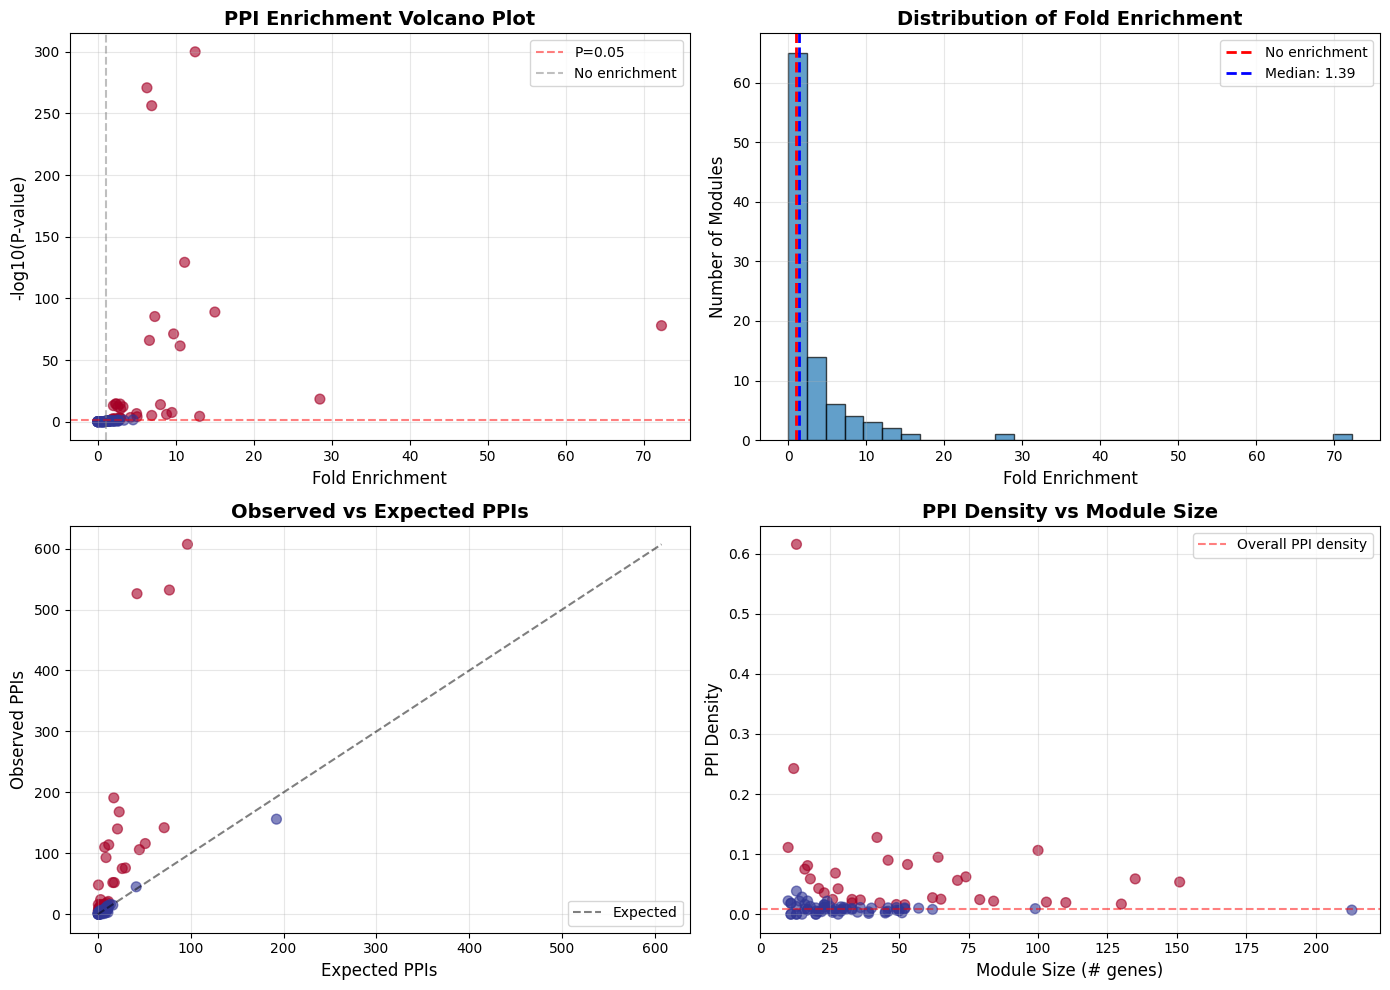

Saved enrichment visualization to ./ModuleViewer_files/PPI_enrichment_analysis.png/pdf


In [13]:
# Visualize PPI enrichment results

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Volcano plot: Fold enrichment vs -log10(p-value)
ax = axes[0, 0]
enrichment_df['neg_log10_pval'] = -np.log10(enrichment_df['P_value'] + 1e-300)  # Add small value to avoid log(0)
scatter = ax.scatter(enrichment_df['Fold_enrichment'], 
                    enrichment_df['neg_log10_pval'],
                    c=enrichment_df['FDR'] < 0.05, 
                    cmap='RdYlBu_r',
                    alpha=0.6,
                    s=50)
ax.axhline(-np.log10(0.05), color='red', linestyle='--', alpha=0.5, label='P=0.05')
ax.axvline(1, color='gray', linestyle='--', alpha=0.5, label='No enrichment')
ax.set_xlabel('Fold Enrichment', fontsize=12)
ax.set_ylabel('-log10(P-value)', fontsize=12)
ax.set_title('PPI Enrichment Volcano Plot', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# 2. Distribution of fold enrichments
ax = axes[0, 1]
ax.hist(enrichment_df['Fold_enrichment'], bins=30, edgecolor='black', alpha=0.7)
ax.axvline(1, color='red', linestyle='--', linewidth=2, label='No enrichment')
ax.axvline(enrichment_df['Fold_enrichment'].median(), color='blue', linestyle='--', 
          linewidth=2, label=f'Median: {enrichment_df["Fold_enrichment"].median():.2f}')
ax.set_xlabel('Fold Enrichment', fontsize=12)
ax.set_ylabel('Number of Modules', fontsize=12)
ax.set_title('Distribution of Fold Enrichment', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# 3. Observed vs Expected PPIs
ax = axes[1, 0]
ax.scatter(enrichment_df['N_PPIs_expected'], enrichment_df['N_PPIs_observed'], 
          c=enrichment_df['FDR'] < 0.05, cmap='RdYlBu_r', alpha=0.6, s=50)
max_val = max(enrichment_df['N_PPIs_expected'].max(), enrichment_df['N_PPIs_observed'].max())
ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.5, label='Expected')
ax.set_xlabel('Expected PPIs', fontsize=12)
ax.set_ylabel('Observed PPIs', fontsize=12)
ax.set_title('Observed vs Expected PPIs', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# 4. PPI density vs module size
ax = axes[1, 1]
scatter = ax.scatter(enrichment_df['N_genes'], enrichment_df['PPI_density'],
                    c=enrichment_df['FDR'] < 0.05, cmap='RdYlBu_r', alpha=0.6, s=50)
ax.axhline(total_observed_ppis / total_possible_ppis, color='red', linestyle='--', 
          alpha=0.5, label='Overall PPI density')
ax.set_xlabel('Module Size (# genes)', fontsize=12)
ax.set_ylabel('PPI Density', fontsize=12)
ax.set_title('PPI Density vs Module Size', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('./ModuleViewer_files/PPI_enrichment_analysis.png', dpi=300, bbox_inches='tight')
plt.savefig('./ModuleViewer_files/PPI_enrichment_analysis.pdf', dpi=300, bbox_inches='tight')
plt.show()

print("Saved enrichment visualization to ./ModuleViewer_files/PPI_enrichment_analysis.png/pdf")